1. Imports

In [26]:
from pathlib import Path

import numpy as np
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
import time

RNG = np.random.default_rng(42)

2. Configuração

In [27]:
def resolve_data_parquet() -> Path:
    """Repo root: data/Indian.... ; cwd em notebooks/: sobe um nível (evita ../data quebrado)."""
    name = Path("data") / "Indian_Weather_Dataset.parquet"
    for base in (Path.cwd(), Path.cwd().parent):
        p = (base / name).resolve()
        if p.is_file():
            return p
    raise FileNotFoundError(
        "Não encontrei Indian_Weather_Dataset.parquet em ./data/ nem ../data/. "
        "Coloque o Parquet em BigData/data/ e use cwd = raiz do repo ou pasta notebooks/."
    )


DATA_PATH = str(resolve_data_parquet())

# Mesmas frações que scripts/split_temporal.py (T021)
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15

BATCH_SIZE = 8192
EPOCHS = 3
LR = 0.001

TARGET = "rain_label"

CAT_COLS = ["state", "city", "crops"]

NUM_COLS = [
    "lat","lon","temperature_C","humidity_pct","pressure_hPa",
    "dew_point_C","pressure_trend","solar_radiation_Wm2",
    "wind_speed_ms","cloud_cover_pct","hour","month",
    "wind_dir_sin","wind_dir_cos","et0_mm"
]

3. Ativações e loss

In [28]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -40, 40)))

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

def bce(y, yhat):
    eps = 1e-7
    yhat = np.clip(yhat, eps, 1 - eps)
    y = np.asarray(y, dtype=np.float64)
    term = -(y * np.log(yhat) + (1 - y) * np.log(1 - yhat))
    return float(np.nanmean(term))

4. Modelo

In [29]:
class MLP:
    def __init__(self, input_dim):
        scale = 0.01
        self.W1 = RNG.normal(size=(input_dim, 64)) * scale
        self.b1 = np.zeros((1, 64))

        self.W2 = RNG.normal(size=(64, 32)) * scale
        self.b2 = np.zeros((1, 32))

        self.W3 = RNG.normal(size=(32, 1)) * scale
        self.b3 = np.zeros((1, 1))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = relu(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        self.out = sigmoid(self.z3)
        return self.out

    def backward(self, X, y, lr):
        n = X.shape[0]
        dz3 = (self.out - y) / n
        db3 = np.sum(dz3, axis=0, keepdims=True)
        dW3 = self.a2.T @ dz3

        dz2 = (dz3 @ self.W3.T) * relu_grad(self.z2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dW2 = self.a1.T @ dz2

        dz1 = (dz2 @ self.W2.T) * relu_grad(self.z1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        dW1 = X.T @ dz1

        self.W3 -= lr * dW3
        self.b3 -= lr * db3
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

5. Dataset

In [30]:
def temporal_split_filters(dataset, train_frac: float, val_frac: float):
    """Split temporal alinhado a scripts/split_temporal.py (T021): ordena por datetime e corta por frações."""
    dt_tbl = dataset.to_table(columns=["datetime"])
    dt = dt_tbl.column(0).combine_chunks()
    if not pa.types.is_timestamp(dt.type):
        dt = pc.cast(dt, pa.timestamp("ms"))
    order = pc.sort_indices(dt)
    dt_sorted = pc.take(dt, order)
    n = len(dt_sorted)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    n_test = n - n_train - n_val
    if min(n_train, n_val, n_test) < 1:
        raise ValueError(f"Dataset demasiado pequeno para split 70/15/15: n={n}")
    cut_tv = dt_sorted[n_train]
    cut_vt = dt_sorted[n_train + n_val]
    train_filter = pc.field("datetime") < cut_tv
    val_filter = (pc.field("datetime") >= cut_tv) & (pc.field("datetime") < cut_vt)
    test_filter = pc.field("datetime") >= cut_vt
    meta = {"n": n, "n_train": n_train, "n_val": n_val, "n_test": n_test}
    return train_filter, val_filter, test_filter, meta


dataset = ds.dataset(DATA_PATH, format="parquet")
train_filter, val_filter, test_filter, SPLIT_META = temporal_split_filters(
    dataset, TRAIN_FRAC, VAL_FRAC
)
print(
    "Split T021:", SPLIT_META, "| train rows:",
    dataset.to_table(columns=["datetime"], filter=train_filter).num_rows,
)

Split T021: {'n': 46082160, 'n_train': 32257511, 'n_val': 6912324, 'n_test': 6912325} | train rows: 32257338


6. Categorias (one-hot simples)

In [31]:
def build_maps():
    maps = {}
    for col in CAT_COLS:
        vals = dataset.to_table(columns=[col])[col].to_pylist()
        maps[col] = {v:i for i,v in enumerate(set(vals))}
    return maps

cat_maps = build_maps()

7. Normalização (treino)

In [32]:
def get_stats():
    table = dataset.to_table(columns=NUM_COLS, filter=train_filter)
    if table.num_rows == 0:
        raise ValueError(
            "Treino vazio: train_filter não cobre nenhuma linha. Verifique DATA_PATH e o split temporal."
        )
    means, stds = [], []
    for col in NUM_COLS:
        arr = np.asarray(table[col], dtype=np.float64)
        m = np.nanmean(arr)
        s = np.nanstd(arr)
        if not np.isfinite(m):
            raise ValueError(f"Média não finita na coluna numérica '{col}' (treino).")
        stds.append(float(s) if s > 1e-12 else 1.0)
        means.append(float(m))
    return np.array(means), np.array(stds)


means, stds = get_stats()

8. Batch → NumPy

In [33]:
def to_xy(batch):
    d = batch.to_pydict()

    Xn = np.stack(
        [np.asarray(d[c], dtype=np.float64) for c in NUM_COLS],
        axis=1,
    )
    Xn = (Xn - means) / stds
    Xn = np.nan_to_num(Xn, nan=0.0, posinf=0.0, neginf=0.0)

    cats = []
    for c in CAT_COLS:
        idx = np.array([cat_maps[c].get(v, 0) for v in d[c]], dtype=np.int64)
        oh = np.zeros((len(idx), len(cat_maps[c])))
        oh[np.arange(len(idx), dtype=np.int64), idx] = 1
        cats.append(oh)

    X = np.concatenate([Xn] + cats, axis=1)
    y = np.nan_to_num(np.asarray(d[TARGET], dtype=np.float64), nan=0.0).reshape(-1, 1)

    return X.astype(np.float32), y.astype(np.float32)

9. Treino

In [34]:
input_dim = len(NUM_COLS) + sum(len(cat_maps[c]) for c in CAT_COLS)
model = MLP(input_dim)

train_loss_hist = []
val_loss_hist = []

start = time.time()

for epoch in range(EPOCHS):
    losses = []

    scanner = dataset.scanner(
        columns=NUM_COLS + CAT_COLS + [TARGET],
        filter=train_filter,
        batch_size=BATCH_SIZE,
    )

    for batch in scanner.to_batches():
        X, y = to_xy(batch)
        if X.shape[0] == 0:
            continue

        pred = model.forward(X)
        loss = bce(y, pred)
        if not np.isfinite(loss):
            raise RuntimeError("Loss não finita; verifique dados e normalização.")

        model.backward(X, y, LR)
        losses.append(loss)

    if not losses:
        raise RuntimeError(
            "Nenhum batch de treino percorrido — train_filter ou DATA_PATH incorrectos, "
            "ou colunas em falta no Parquet."
        )
    train_loss = float(np.mean(losses))
    train_loss_hist.append(train_loss)

    print(f"Epoch {epoch+1} | loss={train_loss:.4f}")

Epoch 1 | loss=0.4861
Epoch 2 | loss=0.3453
Epoch 3 | loss=0.3156


10. Avaliação

In [35]:
def evaluate(filt):
    scanner = dataset.scanner(
        columns=NUM_COLS+CAT_COLS+[TARGET],
        filter=filt,
        batch_size=BATCH_SIZE
    )

    tp=fp=tn=fn=0

    for batch in scanner.to_batches():
        X,y = to_xy(batch)
        p = model.forward(X) >= 0.5

        tp += np.sum((p==1)&(y==1))
        tn += np.sum((p==0)&(y==0))
        fp += np.sum((p==1)&(y==0))
        fn += np.sum((p==0)&(y==1))

    acc = (tp+tn)/(tp+tn+fp+fn)
    prec = tp/(tp+fp+1e-9)
    rec = tp/(tp+fn+1e-9)
    f1 = 2*prec*rec/(prec+rec+1e-9)

    return acc,prec,rec,f1

print("VAL:", evaluate(val_filter))
print("TEST:", evaluate(test_filter))

VAL: (np.float64(0.910182450938353), np.float64(0.0), np.float64(0.0), np.float64(0.0))
TEST: (np.float64(0.9278162539793863), np.float64(0.0), np.float64(0.0), np.float64(0.0))


11. Gráfico

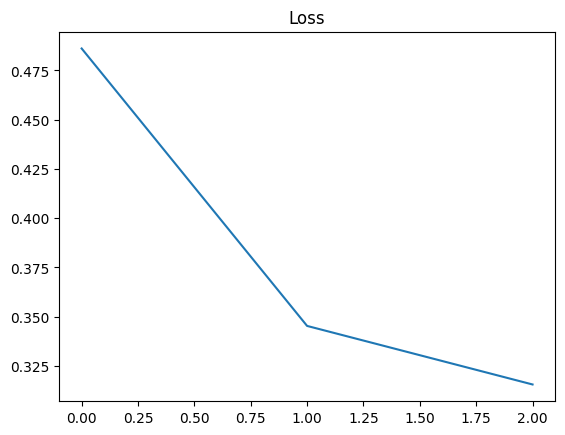

In [36]:
plt.plot(train_loss_hist)
plt.title("Loss")
plt.show()